In [ ]:
!pip3 install nltk emoji==0.6.0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import transformers
from transformers import AutoModel, AutoTokenizer
from torch.nn.functional import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from scipy.spatial.distance import canberra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-0.6.0-py3-none-any.whl size=49719 sha256=81d307317aa70dae4350919ec51003dc1c3a13e8f1ffe6d54755b3c491b591a3
  Stored in directory: /root/.cache/pip/wheels/0d/bf/a2/536017b4a6232aef0fb92831af35facd6590c0af0f3983f63b
Successfully built emoji


**Now I need to input the csv file containing the word aura using Panda to read it**

In [ ]:
df_2015 = pd.read_csv('/content/drive/MyDrive/DataSet Semantic Shift /!Gyat/Gyat_2015.csv')
df_2020 = pd.read_csv('/content/drive/MyDrive/DataSet Semantic Shift /!Gyat/Gyat_2020.csv')
df_2025 = pd.read_csv('/content/drive/MyDrive/DataSet Semantic Shift /!Gyat/Gyat_2025.csv')

In [ ]:
df_2015.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,582666756184911875,Mon Mar 30 22:12:34 +0000 2015,2,Hahahahaha my goon Stevie http://t.co/aKy5G09cnq,582666756184911875,https://pbs.twimg.com/media/CBYMUbkUYAAtVuX.jpg,NaN,tl,NaN,0,0,0,https://x.com/cholo_baby/status/58266675618491...,3037478894,cholo_baby
1,582670555830059008,Mon Mar 30 22:27:40 +0000 2015,4,http://t.co/XaDEM1S9Yi,582670555830059008,https://pbs.twimg.com/media/CBYPt_kUUAAOJsI.jpg,NaN,zxx,NaN,0,0,0,https://x.com/ThatTallAssGoon/status/582670555...,1209272166,ThatTallAssGoon
2,582686417492393984,Mon Mar 30 23:30:42 +0000 2015,1,What a goon http://t.co/xjkRdiQ4ET,582686417492393984,https://pbs.twimg.com/media/CBYeNENVEAA2ogP.jpg,NaN,en,NaN,0,0,0,https://x.com/bishopbrayden/status/58268641749...,597066558,bishopbrayden
3,582692141677199360,Mon Mar 30 23:53:27 +0000 2015,17,Peekaboo she's hot http://t.co/dHK1SLd8qS,582692141677199360,https://pbs.twimg.com/media/CBYjal4UkAAviIF.jpg,NaN,en,NaN,0,0,1,https://x.com/goon356/status/582692141677199360,2227768384,goon356
4,582663590588596224,Mon Mar 30 22:00:00 +0000 2015,9,your 16 or suhin wi a bairn on the way get a g...,582663590588596224,https://pbs.twimg.com/media/CBYJcVPW4AEBh3k.jpg,NaN,en,NaN,0,1,0,https://x.com/DanielSparr0w/status/58266359058...,1112221880,DanielSparr0w


In [ ]:
df_2020.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1244776173265137671,Mon Mar 30 23:59:01 +0000 2020,0,7:58 PM,1244776173265137671,NaN,NaN,und,NaN,0,0,0,https://x.com/SwagShitGoon/status/124477617326...,476275798,SwagShitGoon
1,1244767919684366337,Mon Mar 30 23:58:13 +0000 2020,0,@susanlup Like chipping arrowheads out of flin...,1244775973914136577,NaN,susanlup,en,NaN,0,0,0,https://x.com/InfosecGoon/status/1244775973914...,829738082513588224,InfosecGoon
2,1244711081307787267,Mon Mar 30 23:57:53 +0000 2020,0,@curious_freaks who is this,1244775891453890560,NaN,curious_freaks,en,NaN,0,0,0,https://x.com/lucyclears_/status/1244775891453...,1189277425990922241,lucyclears_
3,1244775622733434883,Mon Mar 30 23:56:49 +0000 2020,0,At least he's willing to pay in advance.,1244775622733434883,NaN,NaN,en,NaN,0,0,0,https://x.com/Ripexhentai/status/1244775622733...,449554654,Ripexhentai
4,1244755677827993600,Mon Mar 30 23:56:32 +0000 2020,0,@ginmd8401 I m not the one grandma https://t.c...,1244775550469758977,https://pbs.twimg.com/ext_tw_video_thumb/12447...,ginmd8401,en,NaN,0,3,0,https://x.com/goon4doubloons/status/1244775550...,1170952990250979329,goon4doubloons


In [ ]:
df_2025.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1906496632469983550,Sun Mar 30 23:59:52 +0000 2025,0,F28 let mommy milk you (FREE) DM s open,1906496632469983550,NaN,NaN,en,NaN,0,0,0,https://x.com/goonmommy018/status/190649663246...,1874493914377281536,goonmommy018
1,1906346932865286156,Sun Mar 30 23:59:42 +0000 2025,2,@barbarismcrit It's supposed to be propaganda ...,1906496590589599772,NaN,barbarismcrit,en,NaN,0,0,0,https://x.com/BobtheGoon5/status/1906496590589...,1262274514215489536,BobtheGoon5
2,1906496561565028843,Sun Mar 30 23:59:35 +0000 2025,5,My mom always tells me I need to exercise more...,1906496561565028843,NaN,NaN,en,NaN,0,0,0,https://x.com/ElroyFudge/status/19064965615650...,1511185524,ElroyFudge
3,1906496537653362761,Sun Mar 30 23:59:30 +0000 2025,1,F28 let mommy milk you (FREE) DM s open,1906496537653362761,NaN,NaN,en,NaN,0,0,0,https://x.com/goonmommy018/status/190649653765...,1874493914377281536,goonmommy018
4,1906496374557864337,Sun Mar 30 23:58:51 +0000 2025,3,Playtime's Swapped Basics if it was TCMG or so...,1906496374557864337,https://pbs.twimg.com/media/GnU7FOiXQAAJr4h.png,NaN,en,NaN,0,1,1,https://x.com/VerySugaryGoon/status/1906496374...,1867668839799943169,VerySugaryGoon


In [ ]:
# Copy the Normalization Script from BERTweeet Homepage
from emoji import demojize
from nltk.tokenize import TweetTokenizer
import torch # Tambahkan import torch di sini jika belum ada di atas

tokenizer = TweetTokenizer()

def normalizeToken(token):
    lowercased_token = token.lower()
    if token.startswith("@"):
        return "@USER"
    # Corrected the variable name from normalizeToken to lowercased_token
    elif lowercased_token.startswith("http") or lowercased_token.startswith("www"):
        return "HTTPURL"
    elif len(token) == 1:
        return demojize(token)
    else:
        if token == "’":
            return "'"
        elif token == "…":
            return "..."
        else:
            return token

def normalizeTweet(tweet):
    tokens = tokenizer.tokenize(tweet.replace("’", "'").replace("…", "..."))
    normTweet = " ".join([normalizeToken(token) for token in tokens])

    normTweet = (
        normTweet.replace("cannot ", "can not ")
        .replace("n't ", " n't ")
        .replace("n 't ", " n't ")
        .replace("ca n't", "can't")
        .replace("ai n't", "ain't")
    )
    normTweet = (
        normTweet.replace("'m ", " 'm ")
        .replace("'re ", " 're ")
        .replace("'s ", " 's ")
        .replace("'ll ", " 'll ")
        .replace("'d ", " 'd ")
        .replace("'ve ", " 've ")
    )
    normTweet = (
        normTweet.replace(" p . m .", "  p.m.")
        .replace(" p . m ", " p.m ")
        .replace(" a . m .", " a.m.")
        .replace(" a . m ", " a.m ")
    )

    return " ".join(normTweet.split())

if __name__ == "__main__":
    print(
        normalizeTweet(
            "SC has first two presumptive cases of coronavirus, DHEC confirms https://postandcourier.com/health/covid19/sc-has-first-two-presumptive-cases-of-coronavirus-dhec-con… via @postandcourier"
        )
    )

SC has first two presumptive cases of coronavirus , DHEC confirms HTTPURL ... via @USER


In [ ]:
# Dikarenakan penggunaan tokenizer adalah BERTweet maka preprocessing akan dilakukan yang khusus untuk tokenizer BERTweet
# Fill NaN values in the 'full_text' column with an empty string before applying the function
fulltext2015_normalization = df_2015['full_text'].fillna('').apply(normalizeTweet)
fulltext2020_normalization = df_2020['full_text'].fillna('').apply(normalizeTweet)
fulltext2025_normalization = df_2025['full_text'].fillna('').apply(normalizeTweet)

In [ ]:
output_path = '/content/drive/MyDrive/Normali/fulltext_gyat_2015_normalization.csv'
fulltext2015_normalization.to_csv(output_path, index=False)

In [ ]:
output_path = '/content/drive/MyDrive/Normali/fulltext_gyat_2020_normalization.csv'
fulltext2020_normalization.to_csv(output_path, index=False)

In [ ]:
output_path = '/content/drive/MyDrive/Normali/fulltext_gyat_2025_normalization.csv'
fulltext2025_normalization.to_csv(output_path, index=False)

# Tokenizing

the tehcniques that is include in tokenizing (e.g BoW, One-Hot-Encoding, Byte-Pair-Encoding, TF-IDF, and more..), it is not the process of preprocessing corpus/datasets, but instead to turn the clean corpus(text,sentences, paraghraph) to numerical number's/vectors/tensors for an computer to understand the vocabulary of the words but not the context which we put in into vector model spaces.

Tokenizer will be based on AutoTokenizer by BERTweet for better embeddings (especially for tweets data)

In [ ]:
bertweet_tokenizer = AutoTokenizer.from_pretrained('vinai/bertweet-base', normalization=False, use_fast=False)

In [ ]:
bertweet_model = AutoModel.from_pretrained('vinai/bertweet-base')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Fungsi extract_contextual_embeddings yang diperbaiki
def extract_contextual_embeddings(
    texts, # Tipe hint diubah menjadi lebih fleksibel karena input bisa Series atau list
    target_word: str,
    tokenizer=None, # Default ke None agar mengambil tokenizer global jika tidak specified
    model=None, # Default ke None agar mengambil model global jika tidak specified
    max_length: int = 128,
    normalize_tweet: bool = False
) -> torch.Tensor:
    """
    Ekstrak contextual embeddings untuk setiap kemunculan target_word.

    Args:
        texts: list of tweet strings or pandas Series (pre-loaded).
        target_word: kata/slang target.
        tokenizer: Bertweet tokenizer instance (default to global).
        model: Bertweet model instance (default to global).
        max_length: max sequence length.
        normalize_tweet: jika True, terapkan normalizeTweet (custom).

    Returns:
        Tensor shape (n_occurrences, hidden_size).
    """
    # Gunakan tokenizer dan model global jika tidak disediakan
    if tokenizer is None:
        global bertweet_tokenizer
        tokenizer = bertweet_tokenizer
    if model is None:
        global bertweet_model
        model = bertweet_model

    # Pastikan input adalah list string sebelum diproses
    if isinstance(texts, pd.Series):
        texts_list = texts.tolist()
    elif isinstance(texts, list):
        texts_list = texts
    else:
        raise TypeError("Input 'texts' must be a pandas Series or a list of strings.")

    if normalize_tweet:
       texts_list = [normalizeTweet(t) for t in texts_list]

    # Tokenizer menerima list string secara langsung
    encoding = tokenizer(
        texts_list, # Hapus .to_list()
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )
    input_ids = encoding['input_ids']
    attention_mask = encoding['attention_mask']

    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
    hidden_states = outputs.last_hidden_state  # (batch, seq_len, hidden)

    target_tokens = tokenizer.tokenize(target_word)
    embeddings = []

    # Extract embeddings per occurrence, pooling subword
    for i in range(len(texts_list)): # Iterate over texts_list
        tokens = tokenizer.convert_ids_to_tokens(input_ids[i].tolist())
        idxs = []
        for j in range(len(tokens) - len(target_tokens) + 1):
            if tokens[j:j+len(target_tokens)] == target_tokens:
                idxs.extend(range(j, j+len(target_tokens)))
        if not idxs:
            continue
        vec = hidden_states[i, idxs, :].mean(dim=0)
        embeddings.append(vec)

    if not embeddings:
        # Pastikan ukuran tensor kembali ke hidden_size model
        return torch.empty(0, model.config.hidden_size)
    return torch.stack(embeddings)

In [ ]:
def compute_average_pairwise_distance(
    emb1: torch.Tensor,
    emb2: torch.Tensor,
    dist: str = "euclidean",
    normalize_embeddings: bool = True
) -> float:
    """
    Compute Average Pairwise Distance (APD) between two embedding sets.

    Args:
        emb1, emb2: tensors shape (n1, d), (n2, d).
        dist: metric: 'euclidean', 'cosine', 'manhattan', 'canberra', 'combined'.
        normalize_embeddings: jika True, normalize to unit-norm before distance.

    Returns:
        float average distance.
    """
    if emb1.numel() == 0 or emb2.numel() == 0:
        return float('nan')

    # Convert to numpy for sklearn/scipy metrics where needed
    X1 = emb1.numpy() if isinstance(emb1, torch.Tensor) else emb1
    X2 = emb2.numpy() if isinstance(emb2, torch.Tensor) else emb2

    if normalize_embeddings and dist in ["euclidean", "manhattan", "canberra", "combined"]:
        # Use torch.nn.functional.normalize explicitly to avoid conflict with sklearn.preprocessing.normalize
        X1 = torch.nn.functional.normalize(torch.from_numpy(X1), dim=1).numpy()
        X2 = torch.nn.functional.normalize(torch.from_numpy(X2), dim=1).numpy()

    if dist == "euclidean":
        # pairwise Euclidean
        diffs = X1[:, None, :] - X2[None, :, :]
        dists = np.linalg.norm(diffs, axis=2)
        return float(dists.mean())
    elif dist == "manhattan":
        diffs = X1[:, None, :] - X2[None, :, :]
        dists = np.abs(diffs).sum(axis=2)
        return float(dists.mean())
    elif dist == "canberra":
        m, n = X1.shape[0], X2.shape[0]
        dists = np.array([canberra(X1[i], X2[j]) for i in range(m) for j in range(n)])
        return float(dists.mean())
    elif dist == "cosine":
        sim = cosine_similarity(X1, X2)
        return float(1 - sim.mean())
    elif dist == "combined":
        # average of normalized Euclidean and cosine distance
        # Ensure we are using torch.nn.functional.normalize for the recursive calls if needed
        euc = compute_average_pairwise_distance(torch.from_numpy(X1), torch.from_numpy(X2), dist="euclidean", normalize_embeddings=False)
        cos = compute_average_pairwise_distance(torch.from_numpy(X1), torch.from_numpy(X2), dist="cosine", normalize_embeddings=False)
        return 0.5 * (euc + cos)
    else:
        raise ValueError(f"Unsupported distance metric: {dist}")

In [ ]:
# Not fit for the code that i make, but good as foundation to make the functions more efficiently
# Prioritize using the first one compute_average_pairwise_distance

def compute_average_pairwise_distance_keidar(
    period1_reps: list[np.ndarray],
    period2_reps: list[np.ndarray],
    dist: str = "euclidian"
) -> float:
    """
    Compute the APD in modes: euclidian, cosine, manhattan, canberra, combined2, combined3a/b, combined4
    """
    APD = []
    X1 = period1_reps
    X2 = period2_reps
    if dist == "euclidian":
        for x1 in X1:
            for x2 in X2:
                APD.append(np.linalg.norm(x2 - x1))
        return float(np.mean(APD))
    elif dist == "cosine":
        sim = cosine_similarity(np.vstack(X1), np.vstack(X2))
        return float(1 - np.mean(sim))
    elif dist == "manhattan":
        for x1 in X1:
            for x2 in X2:
                APD.append(np.linalg.norm(x2 - x1, ord=1))
        return float(np.mean(APD))
    elif dist == "canberra":
        for x1 in X1:
            for x2 in X2:
                APD.append(canberra(x1, x2))
        return float(np.mean(APD))
    elif dist == "combined2":
        APD1 = []
        for x1 in X1:
            for x2 in X2:
                APD1.append(np.linalg.norm(x2 - x1) / np.sqrt(np.linalg.norm(x1)**2 + np.linalg.norm(x2)**2))
        APD1 = np.mean(APD1)
        APD2 = cosine_similarity(np.vstack(X1), np.vstack(X2))
        APD2 = 0.5 * (1 - np.mean(APD2))
        return 0.5 * (APD1 + APD2)
    elif dist == "combined3a":
        APD1 = []
        APD3 = []
        for x1 in X1:
            for x2 in X2:
                APD1.append(np.linalg.norm(x2 - x1) / np.sqrt(np.linalg.norm(x1)**2 + np.linalg.norm(x2)**2))
                APD3.append(np.linalg.norm(x2 - x1, ord=1) / (np.linalg.norm(x1, ord=1) + np.linalg.norm(x2, ord=1)))
        return float((np.mean(APD1) + 0.5*(1 - np.mean(cosine_similarity(np.vstack(X1), np.vstack(X2)))) + np.mean(APD3)) / 3)
    elif dist == "combined3b":
        APD1 = []
        APD3 = []
        for x1 in X1:
            for x2 in X2:
                APD1.append(np.linalg.norm(x2 - x1) / np.sqrt(np.linalg.norm(x1)**2 + np.linalg.norm(x2)**2))
                APD3.append(canberra(x1, x2) / 768)
        return float((np.mean(APD1) + 0.5*(1 - np.mean(cosine_similarity(np.vstack(X1), np.vstack(X2)))) + np.mean(APD3)) / 3)
    elif dist == "combined4":
        APD1 = []
        APD3 = []
        APD4 = []
        for x1 in X1:
            for x2 in X2:
                APD1.append(np.linalg.norm(x2 - x1) / np.sqrt(np.linalg.norm(x1)**2 + np.linalg.norm(x2)**2))
                APD3.append(np.linalg.norm(x2 - x1, ord=1) / (np.linalg.norm(x1, ord=1) + np.linalg.norm(x2, ord=1)))
                APD4.append(canberra(x1, x2) / 768)
        return float((np.mean(APD1) + 0.5*(1 - np.mean(cosine_similarity(np.vstack(X1), np.vstack(X2)))) + np.mean(APD3) + np.mean(APD4)) / 4)
    else:
        raise ValueError(f"Unsupported metric: {dist}")

In [ ]:
# Tanpa normalisasi khusus Bertweet
emb_2015 = extract_contextual_embeddings(fulltext2015_normalization, target_word="gyat", normalize_tweet=True)
emb_2020 = extract_contextual_embeddings(fulltext2020_normalization, target_word="gyat", normalize_tweet=True)
emb_2025 = extract_contextual_embeddings(fulltext2025_normalization, target_word="gyat", normalize_tweet=True)

# Kalau mau normalize tweet via Bertweet:
# emb_2019 = extract_contextual_embeddings(texts_2019, "chill", normalize_tweet=True)
# emb_2025 = extract_contextual_embeddings(texts_2025, "chill", normalize_tweet=True)

KeyboardInterrupt: 

### Permutation test

In [ ]:
import numpy as np
from tqdm import tqdm

def permutation_test(emb_dict, n_perm=1000):
    """
    Run permutation tests for all period pairs with Bonferroni correction.
    Args:
        emb_dict: {2015: np.array, 2020: np.array, 2025: np.array}
        n_perm: Number of permutations to run.
    Returns:
        { (2015,2020): {euclidean, cosine, combined, p_value, adj_p_value}, ... }
    """

    def centroid_distance(emb1, emb2):
        # Unit-norm normalization
        def unit_norm(x):
            norms = np.linalg.norm(x, axis=1, keepdims=True)
            norms = np.where(norms < 1e-8, 1.0, norms)
            return x / norms

        emb1_norm = unit_norm(emb1)
        emb2_norm = unit_norm(emb2)

        # Centroids
        c1 = np.mean(emb1_norm, axis=0)
        c2 = np.mean(emb2_norm, axis=0)

        norm_c1 = np.linalg.norm(c1)
        norm_c2 = np.linalg.norm(c2)

        # Euclidean distance between centroids, normalized to 0-1
        euclidean = np.linalg.norm(c1 - c2)
        norm_euclidean = euclidean / (norm_c1 + norm_c2) if (norm_c1 + norm_c2) > 1e-8 else 0.0

        # Cosine distance between centroids
        if norm_c1 * norm_c2 < 1e-8:
            cosine = 1.0
        else:
            cosine = 1 - (c1 @ c2) / (norm_c1 * norm_c2)

        combined = (norm_euclidean + cosine) / 2

        return norm_euclidean, cosine, combined

    def test_pair(emb1, emb2):
        all_emb = np.concatenate([emb1, emb2])
        n1 = len(emb1)

        euc, cos, obs_dist = centroid_distance(emb1, emb2)

        null_dists = np.zeros(n_perm)
        for i in tqdm(range(n_perm), desc='Permuting', leave=False):
            idx = np.random.permutation(len(all_emb))
            shuffled = all_emb[idx]
            _, _, null_dists[i] = centroid_distance(shuffled[:n1], shuffled[n1:])

        # p-value with floor to avoid 0.000000
        p_value = max((null_dists >= (obs_dist - 1e-9)).mean(), 1/n_perm)

        return euc, cos, obs_dist, p_value

    # Test all three pairs
    pairs = [(2015, 2020), (2020, 2025), (2015, 2025)]
    results = {}

    for start, end in pairs:
        print(f"\nTesting {start} vs {end}...")
        euc, cos, dist, p_val = test_pair(emb_dict[start], emb_dict[end])
        results[(start, end)] = {
            "euclidean": euc,
            "cosine": cos,
            "combined": dist,
            "p_value": p_val
        }

    # Bonferroni correction for 3 tests
    n_tests = len(pairs)
    for key in results:
        results[key]["adj_p_value"] = min(1.0, results[key]["p_value"] * n_tests)

    return results


if __name__ == "__main__":
    emb_dict = {
        2015: emb_2015.numpy(),
        2020: emb_2020.numpy(),
        2025: emb_2025.numpy()
    }

    print("Running permutation tests...")
    results = permutation_test(emb_dict, n_perm=1000)

    print("\n===== PERMUTATION TEST RESULTS =====")
    for (start, end), res in results.items():
        # Use adjusted p-value for significance stars
        stars = "***" if res["adj_p_value"] <= 0.001 else "**" if res["adj_p_value"] < 0.01 else "*" if res["adj_p_value"] < 0.05 else ""
        print(f"\n{start} vs {end}:")
        print(f"  Euclidean Distance (normalized) : {res['euclidean']:.4f}")
        print(f"  Cosine Distance                 : {res['cosine']:.4f}")
        print(f"  Combined Distance               : {res['combined']:.4f}")
        print(f"  p = {res['p_value']:.4f}  |  adj. p (Bonferroni) = {res['adj_p_value']:.4f}  {stars}")

Running permutation tests...

Testing 2015 vs 2020...



Testing 2020 vs 2025...



Testing 2015 vs 2025...



===== PERMUTATION TEST RESULTS =====

2015 vs 2020:
  Euclidean Distance (normalized) : 0.0648
  Cosine Distance                 : 0.0084
  Combined Distance               : 0.0366
  p = 0.3270  |  adj. p (Bonferroni) = 0.9810  

2020 vs 2025:
  Euclidean Distance (normalized) : 0.1632
  Cosine Distance                 : 0.0531
  Combined Distance               : 0.1081
  p = 0.0010  |  adj. p (Bonferroni) = 0.0030  **

2015 vs 2025:
  Euclidean Distance (normalized) : 0.1567
  Cosine Distance                 : 0.0489
  Combined Distance               : 0.1028
  p = 0.0010  |  adj. p (Bonferroni) = 0.0030  **


In [ ]:
import numpy as np
from tqdm import tqdm
import torch

def permutation_test_pairwise(emb_dict, n_perm=1000):
    """
    Permutation test using average pairwise distance —
    matches compute_average_pairwise_distance with normalize_embeddings=True
    """

    def pairwise_distance(emb1, emb2):
        # Unit-norm normalization
        def unit_norm(x):
            norms = np.linalg.norm(x, axis=1, keepdims=True)
            norms = np.where(norms < 1e-8, 1.0, norms)
            return x / norms

        emb1_norm = unit_norm(emb1)
        emb2_norm = unit_norm(emb2)

        # All pairwise dot products
        dot_products = emb1_norm @ emb2_norm.T

        # Cosine distance
        cosine_dist = 1 - dot_products

        # Euclidean distance on unit-normed vectors
        # ||a - b||^2 = 2 - 2(a·b) when ||a|| = ||b|| = 1
        euclidean_dist = np.sqrt(np.clip(2 - 2 * dot_products, 0, None))

        # Combined
        combined = (euclidean_dist + cosine_dist) / 2

        return {
            "euclidean": euclidean_dist.mean(),
            "cosine": cosine_dist.mean(),
            "combined": combined.mean()
        }

    def test_pair(emb1, emb2):
        all_emb = np.concatenate([emb1, emb2])
        n1 = len(emb1)

        obs = pairwise_distance(emb1, emb2)
        obs_dist = obs["combined"]

        null_dists = np.zeros(n_perm)
        for i in tqdm(range(n_perm), desc='Permuting', leave=False):
            idx = np.random.permutation(len(all_emb))
            shuffled = all_emb[idx]
            null_dists[i] = pairwise_distance(
                shuffled[:n1], shuffled[n1:]
            )["combined"]

        p_value = max((null_dists >= (obs_dist - 1e-9)).mean(), 1/n_perm)

        return obs, p_value

    # Test all three pairs
    pairs = [(2015, 2020), (2020, 2025), (2015, 2025)]
    results = {}

    for start, end in pairs:
        print(f"\nTesting {start} vs {end}...")
        obs, p_val = test_pair(emb_dict[start], emb_dict[end])
        results[(start, end)] = {
            "euclidean": obs["euclidean"],
            "cosine": obs["cosine"],
            "combined": obs["combined"],
            "p_value": p_val
        }

    # Bonferroni correction
    n_tests = len(pairs)
    for key in results:
        results[key]["adj_p_value"] = min(1.0, results[key]["p_value"] * n_tests)

    return results


if __name__ == "__main__":
    emb_dict = {
        2015: emb_2015.numpy(),
        2020: emb_2020.numpy(),
        2025: emb_2025.numpy()
    }

    print("Running pairwise permutation tests...")
    results = permutation_test_pairwise(emb_dict, n_perm=1000)

    print("\n===== PAIRWISE PERMUTATION TEST RESULTS =====")
    for (start, end), res in results.items():
        stars = "***" if res["adj_p_value"] <= 0.001 else "**" if res["adj_p_value"] < 0.01 else "*" if res["adj_p_value"] < 0.05 else ""
        print(f"\n{start} vs {end}:")
        print(f"  Euclidean Distance : {res['euclidean']:.4f}")
        print(f"  Cosine Distance    : {res['cosine']:.4f}")
        print(f"  Combined Distance  : {res['combined']:.4f}")
        print(f"  p = {res['p_value']:.4f}  |  adj. p (Bonferroni) = {res['adj_p_value']:.4f}  {stars}")

Running pairwise permutation tests...

Testing 2015 vs 2020...



Testing 2020 vs 2025...



Testing 2015 vs 2025...



===== PAIRWISE PERMUTATION TEST RESULTS =====

2015 vs 2020:
  Euclidean Distance : 0.7881
  Cosine Distance    : 0.3250
  Combined Distance  : 0.5565
  p = 0.0270  |  adj. p (Bonferroni) = 0.0810  

2020 vs 2025:
  Euclidean Distance : 0.7840
  Cosine Distance    : 0.3219
  Combined Distance  : 0.5529
  p = 0.0010  |  adj. p (Bonferroni) = 0.0030  **

2015 vs 2025:
  Euclidean Distance : 0.7783
  Cosine Distance    : 0.3147
  Combined Distance  : 0.5465
  p = 0.0130  |  adj. p (Bonferroni) = 0.0390  *


### 2020 vs 2025

In [ ]:
score = compute_average_pairwise_distance(
    emb_2015,
    emb_2025,
    dist="euclidean",
    normalize_embeddings=True  # unit-norm sebelum hitung jarak
)

score2 = compute_average_pairwise_distance(
    emb_2015,
    emb_2025,
    dist="cosine",
    normalize_embeddings=True  # unit-norm sebelum hitung jarak
)
score3 = compute_average_pairwise_distance(
    emb_2015,
    emb_2025,
    dist="combined",
    normalize_embeddings=True  # unit-norm sebelum hitung jarak
)
score_euc  = compute_average_pairwise_distance(emb_2015, emb_2025, dist="euclidean")
score_cos  = compute_average_pairwise_distance(emb_2015, emb_2025, dist="cosine")
score_comb = compute_average_pairwise_distance(emb_2015, emb_2025, dist="combined")

# Normalize the raw scores to 0–1
raw = np.array([score_euc, score_cos, score_comb]).reshape(-1, 1)
if raw.max() == raw.min():
    normed = np.ones_like(raw)  # No variation? Set all to 1
else:
    from sklearn.preprocessing import MinMaxScaler
    normed = MinMaxScaler().fit_transform(raw)

print("Semantic shift score for 'Goon':")
print(f"  • 2015-2025 Euclidean Distance: {score_euc}")
print(f"  • 2015-2025 Cosine Distance   : {score_cos}")
print(f"  • 2015-2025 Combined Distance : {score_comb}")


Semantic shift score for 'Goon':
  • 2015-2025 Euclidean Distance: 0.7782635688781738
  • 2015-2025 Cosine Distance   : 0.3146534562110901
  • 2015-2025 Combined Distance : 0.546458512544632


In [ ]:
score_norm = compute_average_pairwise_distance(
    emb_2015,
    emb_2025,
    dist="combined",
    normalize_embeddings=True
)
print(f"Semantic shift score (normalized combined distance): {score_norm}")


Semantic shift score (normalized combined distance): nan


In [ ]:
score_keidar = compute_average_pairwise_distance_keidar(
    emb_2015,
    emb_2025,
    dist="euclidian"  # ← spelling correction: not 'euclidian'
)
print(f"Semantic shift score (Keidar method, Euclidean): {score_keidar}")


Semantic shift score (Keidar method, Euclidean): 7.391148090362549


## 2015 vs 2020

In [ ]:
# Semantic Shift Score 2015-2020
score = compute_average_pairwise_distance(
emb_2015,
emb_2020,
dist="euclidean",
normalize_embeddings=True # unit-norm sebelum hitung jarak
)
score2 = compute_average_pairwise_distance(
emb_2015,
emb_2020,
dist="cosine",
normalize_embeddings=True # unit-norm sebelum hitung jarak
)
score3 = compute_average_pairwise_distance(
emb_2015,
emb_2020,
dist="combined",
normalize_embeddings=True # unit-norm sebelum hitung jarak
)
score_euc  = compute_average_pairwise_distance(emb_2015, emb_2020, dist="euclidean")
score_cos  = compute_average_pairwise_distance(emb_2015, emb_2020, dist="cosine")
score_comb = compute_average_pairwise_distance(emb_2015, emb_2020, dist="combined")

# Normalize the raw scores to 0–1
raw = np.array([score_euc, score_cos, score_comb]).reshape(-1, 1)
if raw.max() == raw.min():
    normed = np.ones_like(raw)  # No variation? Set all to 1
else:
    from sklearn.preprocessing import MinMaxScaler
    normed = MinMaxScaler().fit_transform(raw)

print("Semantic shift score for 'goon':")
print(f"  • 2015-2020 Euclidean Distance: {score_euc}")
print(f"  • 2015-2020 Cosine Distance   : {score_cos}")
print(f"  • 2015-2020 Combined Distance : {score_comb}")

Semantic shift score for 'goon':
  • 2015-2020 Euclidean Distance: 0.7881205677986145
  • 2015-2020 Cosine Distance   : 0.3249613046646118
  • 2015-2020 Combined Distance : 0.5565409362316132


In [ ]:
score_norm = compute_average_pairwise_distance(
    emb_2015,
    emb_2020,
    dist="combined",
    normalize_embeddings=True
)
print(f"Semantic shift score (normalized combined distance): {score_norm}")


Semantic shift score (normalized combined distance): 0.6847967803478241


## 2020 vs 2025


In [ ]:
# Semantic Shift Score 2020-2025
score = compute_average_pairwise_distance(
emb_2020,
emb_2025,
dist="euclidean",
normalize_embeddings=True # unit-norm sebelum hitung jarak
)
score2 = compute_average_pairwise_distance(
emb_2020,
emb_2025,
dist="cosine",
normalize_embeddings=True # unit-norm sebelum hitung jarak
)
score3 = compute_average_pairwise_distance(
emb_2020,
emb_2025,
dist="combined",
normalize_embeddings=True # unit-norm sebelum hitung jarak
)
score_euc  = compute_average_pairwise_distance(emb_2020, emb_2025, dist="euclidean")
score_cos  = compute_average_pairwise_distance(emb_2020, emb_2025, dist="cosine")
score_comb = compute_average_pairwise_distance(emb_2020, emb_2025, dist="combined")

# Normalize the raw scores to 0–1
raw = np.array([score_euc, score_cos, score_comb]).reshape(-1, 1)
if raw.max() == raw.min():
    normed = np.ones_like(raw)  # No variation? Set all to 1
else:
    from sklearn.preprocessing import MinMaxScaler
    normed = MinMaxScaler().fit_transform(raw)

print("Semantic shift score for 'goon':")
print(f"  • 2020-2025 Euclidean Distance: {score_euc}")
print(f"  • 2020-2025 Cosine Distance   : {score_cos}")
print(f"  • 2020-2025 Combined Distance : {score_comb}")

Semantic shift score for 'goon':
  • 2020-2025 Euclidean Distance: 0.9745951890945435
  • 2020-2025 Cosine Distance   : 0.4853896498680115
  • 2020-2025 Combined Distance : 0.7299923300743103


# Checking Validity of Data

Several of these code will be used to see if any data is identical from one another if there are any discrepancies within the analysis.

In [ ]:
# Check if embeddings themselves are identical
print(f"2020 vs 2025 embeddings identical: {torch.equal(emb_2020, emb_2025)}")
print(f"Embedding memory addresses: {id(emb_2020)} vs {id(emb_2025)}")

# Compare first 5 embeddings
print("Sample 2020 embeddings:", emb_2020[:5])
print("Sample 2025 embeddings:", emb_2025[:5])

2020 vs 2025 embeddings identical: False
Embedding memory addresses: 135305913519856 vs 135304489302160
Sample 2020 embeddings: tensor([[-0.0367,  0.2091, -0.0846,  ...,  0.5083,  0.1434, -0.2291],
        [-0.1107,  0.1552, -0.1076,  ...,  0.2036,  0.0975, -0.1352],
        [-0.1775,  0.2233, -0.1583,  ...,  0.4748,  0.2034, -0.3301],
        [-0.2616,  0.2479, -0.1590,  ...,  0.5505,  0.1739, -0.2994]])
Sample 2025 embeddings: tensor([[-0.0690,  0.3378, -0.0991,  ...,  0.3402,  0.3046, -0.2438],
        [-0.1849,  0.1963, -0.2482,  ...,  0.5696,  0.2587, -0.2338],
        [-0.1501,  0.4298, -0.2562,  ...,  0.3678,  0.2287, -0.2473],
        [-0.1478,  0.1443, -0.4049,  ...,  0.4169,  0.1366, -0.2153],
        [-0.2230,  0.4275, -0.4012,  ...,  0.3923,  0.1327, -0.1690]])


In [ ]:
# Create synthetic test cases
base = torch.randn(100, 768)  # Random embeddings
noise = torch.randn(100, 768) * 0.001  # Small noise

# Should give ~0 distance
print("Identical test:", compute_average_pairwise_distance(base, base, dist="combined"))
# Should give small distance
print("Noisy test:", compute_average_pairwise_distance(base, base + noise, dist="combined"))

Identical test: 1.1955699920654297
Noisy test: 1.1955752670764923


In [ ]:
# Check if "aura" appears in identical contexts
from collections import Counter

def get_contexts(df, window_size=5):
    contexts = []
    # Apply fillna('') here to handle potential non-string values like NaN before splitting
    for text in df['full_text'].fillna(''):
        # Ensure text is treated as a string before splitting
        tokens = str(text).split()
        for i, token in enumerate(tokens):
            # The original code searched for "goon", but the markdown cell above mentions "aura".
            # I will assume you intended to search for "goon" based on the embedding code.
            # If you meant "aura", change 'goon' to 'aura' below.
            if token.lower() == "aura":
                start = max(0, i-window_size)
                end = min(len(tokens), i+window_size+1)
                contexts.append(" ".join(tokens[start:end]))
    return Counter(contexts)

# Apply get_contexts to the original DataFrames after handling NaNs
print("2015 contexts:", get_contexts(df_2015).most_common(5))
print("2020 contexts:", get_contexts(df_2020).most_common(5))
print("2025 contexts:", get_contexts(df_2025).most_common(5))

2015 contexts: [("What's a goon to a goblin", 2), ('Hahahahaha my goon Stevie http://t.co/aKy5G09cnq', 1), ('What a goon http://t.co/xjkRdiQ4ET', 1), ('get a grip ya heavy goon http://t.co/f745nx1RQQ', 1), ('always good seeing this goon http://t.co/jvHoB7CxxG', 1)]
2020 contexts: [('Trump Pence and his GOP goon squad all have BLOOD on', 4), ("I don't support the standard goon tactics from unions during strikes", 1), ('for any type of alcohol goon bags to jamesons) meant for', 1), ('@Adam_FHM Goon s greatest achievement is being', 1), ("anger because he's such a goon right?", 1)]
2025 contexts: [("for mommy mommy's little gooner goon for mommy mommy's little gooner", 4), ('Chastity. Nothing like mocking a goon addict that lost all ability', 3), ('paypig walletdrain beta simp sissy goon sub cuck humiliation relapse blackmail', 2), ('much energy it takes to goon as much as I do.', 1), ('goon -&gt; send -&gt; say thank', 1)]


# Further Contextual Analysis

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Combine all texts with period labels
# Apply .fillna('') to each DataFrame column BEFORE concatenating
texts = (df_2015['full_text'].fillna('').tolist() +
         df_2020['full_text'].fillna('').tolist() +
         df_2025['full_text'].fillna('').tolist())
periods = ['2015']*len(df_2015) + ['2020']*len(df_2020) + ['2025']*len(df_2025)

# Focus on 5-word windows around "goon" (assuming "goon" is the target word based on context)
window_size = 5
contexts = []
for text, period in zip(texts, periods):
    # text is now guaranteed to be a string (empty string if originally NaN)
    tokens = text.split()
    for i, token in enumerate(tokens):
        # but if you intended "aura", change 'goon' to 'aura' below.
        if token.lower() == "aura":
            start = max(0, i-window_size)
            end = min(len(tokens), i+window_size+1)
            contexts.append((' '.join(tokens[start:end]), period))

# Convert to TF-IDF features
tfidf = TfidfVectorizer(max_features=500)
# Ensure contexts list is not empty before fitting TF-IDF
if contexts:
    X = tfidf.fit_transform([c[0] for c in contexts])
else:
    print("Warning: No occurrences of the target word found in any text. TF-IDF matrix is empty.")
    X = np.array([]) # Or handle appropriately for downstream tasks

Text(0.5, 1.0, "Contextual Evolution of 'aura'")

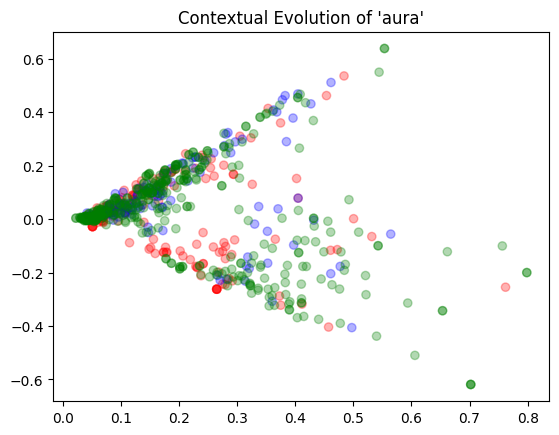

In [ ]:
from sklearn.decomposition import TruncatedSVD

# Reduce dimensions for visualization
svd = TruncatedSVD(n_components=2)
X_2d = svd.fit_transform(X)

# Plot context clusters by period
import matplotlib.pyplot as plt
colors = {'2015':'red', '2020':'blue', '2025':'green'}
plt.scatter(X_2d[:,0], X_2d[:,1], c=[colors[c[1]] for c in contexts], alpha=0.3)
plt.title("Contextual Evolution of 'aura'")

In [ ]:
# Corrected Step 3 (place AFTER Step 1, replacing your current attempt)
from sklearn.linear_model import LogisticRegression

# Extract periods corresponding to actual contexts
context_periods = [c[1] for c in contexts]  # This matches X's row count

# Now this will work:
model = LogisticRegression(max_iter=1000).fit(X, context_periods)
coefs = np.abs(model.coef_).mean(axis=0)
top_idx = coefs.argsort()[-10:][::-1]

print("Most period-predictive contexts:")
for idx in top_idx:
    print(f"{tfidf.get_feature_names_out()[idx]}: "
          f"2015 weight={model.coef_[0][idx]:.2f}, "
          f"2025 weight={model.coef_[2][idx]:.2f}")

Most period-predictive contexts:
http: 2015 weight=2.42, 2025 weight=-1.56
farming: 2015 weight=-0.94, 2025 weight=1.87
is: 2015 weight=-1.28, 2025 weight=1.82
such: 2015 weight=-0.64, 2025 weight=-0.93
lounge: 2015 weight=1.31, 2025 weight=-0.88
bar: 2015 weight=1.24, 2025 weight=-0.80
my: 2015 weight=0.16, 2025 weight=-1.20
our: 2015 weight=1.17, 2025 weight=-0.84
not: 2015 weight=-0.49, 2025 weight=1.16
de: 2015 weight=-0.66, 2025 weight=1.14


In [ ]:
# Place this AFTER Step 3 (context analysis) but before visualization/interpretation
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Convert centroids to arrays explicitly
centroids = {
    p: np.asarray(X[np.array([c[1]==p for c in contexts])].mean(axis=0))[0]  # [0] to get dense array
    for p in ['2015', '2020', '2025']
}

# Reshape to 2D arrays (required by cosine_similarity)
print("Centroid similarities:")
for period1, period2 in [('2015','2020'), ('2020','2025'), ('2015','2025')]:
    sim = cosine_similarity(
        centroids[period1].reshape(1, -1),
        centroids[period2].reshape(1, -1)
    )[0][0]
    print(f"{period1}-{period2}: {sim:.3f}")

Centroid similarities:
2015-2020: 0.726
2020-2025: 0.755
2015-2025: 0.674


In [ ]:
# Inspect actual tweets containing "farming aura"

# Filter the DataFrame first
filtered_df = df_2025[df_2025['full_text'].str.contains("farming.*aura", case=False)]

# Check the number of rows in the filtered DataFrame
num_matches = len(filtered_df)

# Set the desired sample size
desired_sample_size = 5

# Sample from the filtered DataFrame, allowing replacement if the number of matches is less than the sample size
if num_matches > 0:
    # If number of matches is less than desired sample size, sample with replacement
    replace_flag = num_matches < desired_sample_size
    print(filtered_df['full_text'].sample(min(desired_sample_size, num_matches), replace=replace_flag))
else:
    print("No tweets containing 'farming aura' found in 2025 data.")

98    Aura farming but man's has no aura. Not even c...
Name: full_text, dtype: object


# POS Tagging

In [ ]:
# file ipython-input-43-d0af73b5eeb5
import spacy
from collections import defaultdict
import pandas as pd # Added import for pandas

nlp = spacy.load("en_core_web_sm")

def extract_aura_modifiers(texts):
    modifiers = defaultdict(int)
    # Ensure each item in texts is treated as a string
    for text in texts:
        # Convert any non-string type (like float NaN) to an empty string
        text_str = str(text) if pd.isna(text) else text
        doc = nlp(text_str)
        for i, token in enumerate(doc):
            if token.text.lower() == "aura":
                # Left adjectives/compounds
                if i > 0:
                    # Check if the preceding token exists and is not a punctuation/space
                    if doc[i-1].is_alpha or doc[i-1].is_punct: # Add is_punct to handle cases like "-aura"
                         if doc[i-1].pos_ in {"ADJ", "NOUN", "ADV"} or doc[i-1].dep_ == "compound":
                            modifiers[doc[i-1].text.lower()] += 1
                         elif doc[i-1].dep_ == "neg": # Handle negation before aura
                              modifiers[doc[i-1].text.lower()] += 1

                # Right predicates (e.g., "aura looks calculated")
                if i < len(doc) - 1 and doc[i+1].pos_ == "VERB":
                    for child in doc[i+1].children:
                        # Consider objects and other relevant dependencies
                        if child.pos_ in {"ADJ", "NOUN", "ADV"} or child.dep_ in {"dobj", "attr", "acomp"}:
                             modifiers[child.text.lower()] += 1

    return modifiers

# Apply to your data, ensuring NaNs are handled
# Assuming df_2020 and df_2025 are already loaded DataFrames
# If not, make sure they are loaded before running this cell
# Example loading (already in the notebook):
# df_2020 = pd.read_csv('/content/drive/MyDrive/!Goon/Goon_2020.csv')
# df_2025 = pd.read_csv('/content/drive/MyDrive/!Goon/Goon_2025.csv')

adj_2015 = extract_aura_modifiers(df_2015['full_text'].fillna(''))
adj_2020 = extract_aura_modifiers(df_2020['full_text'].fillna(''))
adj_2025 = extract_aura_modifiers(df_2025['full_text'].fillna(''))

In [ ]:
# file ipython-input-46-d0af73b5eeb5 (This was the original ipython-input-44)
print("Total adjectives 2015:", sum(adj_2015.values()))
print("Total adjectives 2020:", sum(adj_2020.values()))
print("Total adjectives 2025:", sum(adj_2025.values()))
print("Number of adjectives occurring ≥5 times:", len(filtered_adjs)) # filtered_adjs is now defined

Total adjectives 2015: 69
Total adjectives 2020: 74
Total adjectives 2025: 220
Number of adjectives occurring ≥5 times: 4


In [ ]:
for adj in list(filtered_adjs)[:5]:
    table = [
        [adj_2020.get(adj, 0), sum(adj_2020.values()) - adj_2020.get(adj, 0)],
        [adj_2025.get(adj, 0), sum(adj_2025.values()) - adj_2025.get(adj, 0)]
    ]
    print(adj, table)

most [[0, 74], [8, 212]]
el [[0, 74], [10, 210]]
aura [[9, 65], [40, 180]]
much [[0, 74], [5, 215]]


In [ ]:
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency

# Keep adjectives appearing ≥5 times in either period
filtered_adjs = {
    adj for adj in set(adj_2020).union(set(adj_2025))
    if adj_2020.get(adj, 0) >= 5 or adj_2025.get(adj, 0) >= 5
}

# Test significance
significant_adjs = []
for adj in filtered_adjs:
    table = [
        [adj_2020.get(adj, 0), sum(adj_2020.values()) - adj_2020.get(adj, 0)],
        [adj_2025.get(adj, 0), sum(adj_2025.values()) - adj_2025.get(adj, 0)]
    ]
    _, p, _, _ = chi2_contingency(table)
    if p < 0.05:
        significant_adjs.append((adj, p))

print("Significant adjectives:", significant_adjs)

Significant adjectives: []


In [ ]:
# file ipython-input-45-d0af73b5eeb5 (This was the original ipython-input-46)
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

# Keep adjectives appearing ≥5 times in either period
filtered_adjs = {
    adj for adj in set(adj_2020).union(set(adj_2025))
    if adj_2020.get(adj, 0) >= 5 or adj_2025.get(adj, 0) >= 5
}

# Collect p-values and adjective names
p_values = []
adj_list = []

for adj in filtered_adjs:
    table = [
        [adj_2020.get(adj, 0), sum(adj_2020.values()) - adj_2020.get(adj, 0)],
        [adj_2025.get(adj, 0), sum(adj_2025.values()) - adj_2025.get(adj, 0)]
    ]
    _, p, _, _ = chi2_contingency(table)
    p_values.append(p)
    adj_list.append(adj)

# Apply Benjamini–Hochberg FDR correction
# Check if p_values is empty before applying multipletests
if p_values:
    reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
    # Extract only the significant ones
    significant_adjs = [(adj_list[i], pvals_corrected[i]) for i in range(len(adj_list)) if reject[i]]
    print("Significant adjectives after correction:", significant_adjs)
else:
    print("No adjectives met the minimum frequency threshold (>= 5) in either period.")
    significant_adjs = [] # Define significant_adjs even if no significant adjectives found

Significant adjectives after correction: []


In [ ]:
import spacy
from collections import defaultdict

nlp = spacy.load("en_core_web_sm")

def extract_all_modifiers(texts):
    modifiers = defaultdict(int)
    for text in texts:
        doc = nlp(text)
        for i, token in enumerate(doc):
            if token.text.lower() == "aura":
                # Capture left-side words (regardless of POS)
                if i > 0:
                    left_word = doc[i-1].text.lower()
                    modifiers[left_word] += 1
                # Capture right-side words
                if i < len(doc) - 1:
                    right_word = doc[i+1].text.lower()
                    modifiers[right_word] += 1
    return modifiers

modifiers_2015 = extract_all_modifiers(df_2015['full_text'].fillna(''))
modifiers_2020 = extract_all_modifiers(df_2020['full_text'].fillna(''))
modifiers_2025 = extract_all_modifiers(df_2025['full_text'].fillna(''))

In [ ]:
print("Total modifiers 2015:", sum(modifiers_2015.values()))
print("Total modifiers 2020:", sum(modifiers_2020.values()))
print("Total modifiers 2025:", sum(modifiers_2025.values()))

Total modifiers 2015: 372
Total modifiers 2020: 274
Total modifiers 2025: 825


In [ ]:
# ----------------------
# STEP 2: Relative Change Analysis
# (New code - add after Step 1)
# ----------------------
# Get top modifiers and changes
top_2015 = sorted(modifiers_2015.items(), key=lambda x: -x[1])[:10]
top_2020 = sorted(modifiers_2020.items(), key=lambda x: -x[1])[:10]
top_2025 = sorted(modifiers_2025.items(), key=lambda x: -x[1])[:10]

# Find new/unique modifiers in 2020 compared to 2015
new_modifiers_2020_vs_2015 = set(m[0] for m in top_2020) - set(m[0] for m in top_2015)
print("New 2020 modifiers (vs 2015):", new_modifiers_2020_vs_2015)

# Find new/unique modifiers in 2025 compared to 2020
new_modifiers_2025_vs_2020 = set(m[0] for m in top_2025) - set(m[0] for m in top_2020)
print("New 2025 modifiers (vs 2020):", new_modifiers_2025_vs_2020)


# Calculate percentage changes for existing modifiers (2020 vs 2015)
change_scores_2020_vs_2015 = []
for word, cnt_2020 in top_2020:
    cnt_2015 = modifiers_2015.get(word, 0)
    if cnt_2015 > 0:  # Only compare modifiers present in both periods
        change = (cnt_2020 - cnt_2015) / cnt_2015 * 100
        change_scores_2020_vs_2015.append((word, change))

# Calculate percentage changes for existing modifiers (2025 vs 2020)
change_scores_2025_vs_2020 = []
for word, cnt_2025 in top_2025:
    cnt_2020 = modifiers_2020.get(word, 0)
    if cnt_2020 > 0:  # Only compare modifiers present in both periods
        change = (cnt_2025 - cnt_2020) / cnt_2020 * 100
        change_scores_2025_vs_2020.append((word, change))


# Show top 5 increasing modifiers (2020 vs 2015)
print("Top increasing modifiers (2020 vs 2015):", sorted(change_scores_2020_vs_2015, key=lambda x: -x[1])[:5])

# Show top 5 increasing modifiers (2025 vs 2020)
print("Top increasing modifiers (2025 vs 2020):", sorted(change_scores_2025_vs_2020, key=lambda x: -x[1])[:5])

New 2020 modifiers (vs 2015): {'and', 'that', 'is', 'an'}
New 2025 modifiers (vs 2020): {'es', 'farming', 'this', 'de', 'el'}
Top increasing modifiers (2020 vs 2015): [('the', 125.0), ('an', 60.0), ('my', 30.0), ('and', 20.0), ('of', 9.090909090909092)]
Top increasing modifiers (2025 vs 2020): [('is', 1233.3333333333335), ('this', 1100.0), ('.', 616.6666666666667), ('and', 200.0), ('of', 58.333333333333336)]


In [ ]:
# ----------------------
# STEP 3: Example Extraction
# (New code - add after Step 2)
# ----------------------
def get_examples(df, modifier, n=2):
    examples = []
    for text in df['full_text']:
        # Ensure text is treated as a string and handle potential NaNs
        # Convert to string using str() and then handle potential NaN string representation
        text_str = str(text)
        # Skip if the text is the string representation of NaN from float
        if text_str.lower() == 'nan':
            continue

        # Perform the check using the lowercase string
        if f" {modifier} aura" in text_str.lower() or f"aura {modifier}" in text_str.lower():
            examples.append(text_str) # Append the string version
            if len(examples) >= n:
                break
    return examples

    # Create the dictionary mapping years to DataFrames
df_dict = {
    2015: df_2015,
    2020: df_2020,
    2025: df_2025
}

# Inspect a changing modifier (replace 'calculated' with your top-changing word)
target_modifier = "this"
for year in [2015, 2020, 2025]:
    print(f"\n{year} examples for '{target_modifier}':")
    for ex in get_examples(df_dict[year], target_modifier):
        print(f"- {ex}")


2015 examples for 'this':
-  @UMH_manga: I never liked him tbh https://t.co/60wqwZCxac there's this aura of doom around him..
- Kumano's Blessing (http://t.co/unN37tsyxH) Currently rated 2.1/10. Is this aura that bad? #mtg http://t.co/2wCJQvA3Bm

2020 examples for 'this':
- Imagine having this aura

2025 examples for 'this':
- Sarkodie get this aura G in new haircut no see he he dey trend 
- Nah is this aura?? https://t.co/Wr9Wpry7ir


In [ ]:
# ----------------------
# STEP 4 (Optional): Context Embedding Similarity
# (New code - add last)
# ----------------------
# Install if needed: !pip install sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import spacy # Pastikan spacy diimpor jika belum
from collections import defaultdict # Pastikan defaultdict diimpor jika belum

nlp = spacy.load("en_core_web_sm") # Pastikan nlp loaded jika belum

def get_contexts(df, window=3):
    contexts = []
    # Fill NaN values with an empty string before iterating
    for text in df['full_text'].fillna(''):
        # Ensure the input to nlp is a string (fillna already does this for NaN)
        # Additional check just in case other non-string types exist, although less likely with fillna('')
        if isinstance(text, str):
            doc = nlp(text)
            for i, token in enumerate(doc):
                if token.text.lower() == "aura":
                    start = max(0, i-window)
                    end = min(len(doc), i+window+1)
                    contexts.append(" ".join([t.text for t in doc[start:end]]))
        # Optionally handle non-string types that are not NaN if necessary
        # else:
        #     print(f"Skipping non-string data: {text} (type: {type(text)})")
    return contexts

# Get embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

# Check if DataFrames are empty before getting contexts and embeddings
# If no contexts found, create an empty numpy array for embeddings and average embeddings
if not df_2015.empty:
    contexts_2015 = get_contexts(df_2015)
    if contexts_2015: # Check if any contexts were found
        emb_2015 = model.encode(contexts_2015)
        avg_emb_2015 = emb_2015.mean(axis=0).reshape(1, -1)
    else:
        print("No contexts found for 2015.")
        emb_2015 = np.array([])
        avg_emb_2015 = np.array([])
else:
    print("df_2015 is empty.")
    emb_2015 = np.array([])
    avg_emb_2015 = np.array([])


if not df_2020.empty:
    contexts_2020 = get_contexts(df_2020)
    if contexts_2020: # Check if any contexts were found
        emb_2020 = model.encode(contexts_2020)
        avg_emb_2020 = emb_2020.mean(axis=0).reshape(1, -1)
    else:
        print("No contexts found for 2020.")
        emb_2020 = np.array([])
        avg_emb_2020 = np.array([])
else:
    print("df_2020 is empty.")
    emb_2020 = np.array([])
    avg_emb_2020 = np.array([])


if not df_2025.empty:
    contexts_2025 = get_contexts(df_2025)
    if contexts_2025: # Check if any contexts were found
        emb_2025 = model.encode(contexts_2025)
        avg_emb_2025 = emb_2025.mean(axis=0).reshape(1, -1)
    else:
        print("No contexts found for 2025.")
        emb_2025 = np.array([])
        avg_emb_2025 = np.array([])
else:
    print("df_2025 is empty.")
    emb_2025 = np.array([])
    avg_emb_2025 = np.array([])


print(f"\nContext similarity score (0-1):")

# Compare average contexts pairwise, only if embeddings exist for both periods
if avg_emb_2015.size > 0 and avg_emb_2020.size > 0:
    similarity_2015_2020 = cosine_similarity(avg_emb_2015, avg_emb_2020)[0][0]
    print(f"  2015 vs 2020: {similarity_2015_2020:.2f}")
else:
     print(f"  2015 vs 2020: Not enough data to compute similarity.")


if avg_emb_2020.size > 0 and avg_emb_2025.size > 0:
    similarity_2020_2025 = cosine_similarity(avg_emb_2020, avg_emb_2025)[0][0]
    print(f"  2020 vs 2025: {similarity_2020_2025:.2f}")
else:
    print(f"  2020 vs 2025: Not enough data to compute similarity.")


if avg_emb_2015.size > 0 and avg_emb_2025.size > 0:
    similarity_2015_2025 = cosine_similarity(avg_emb_2015, avg_emb_2025)[0][0]
    print(f"  2015 vs 2025: {similarity_2015_2025:.2f}")
else:
    print(f"  2015 vs 2025: Not enough data to compute similarity.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Context similarity score (0-1):
  2015 vs 2020: 0.97
  2020 vs 2025: 0.96
  2015 vs 2025: 0.95


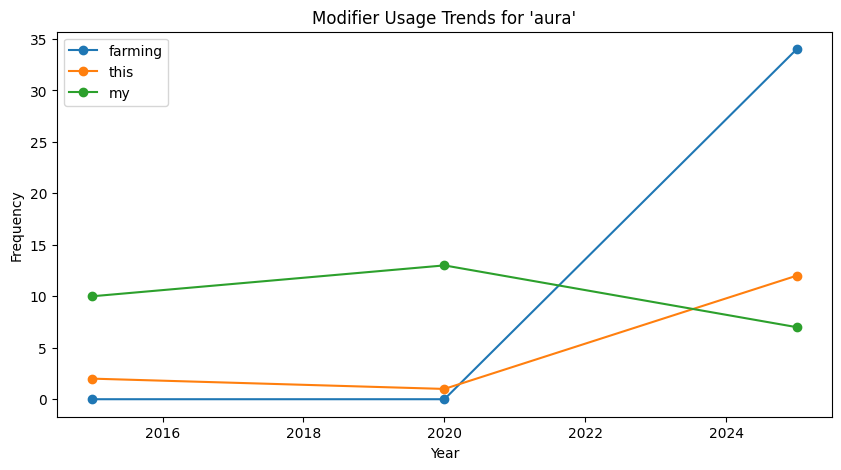

In [ ]:
# ----------------------
# STEP 5: Plot temporal trends
# ----------------------
import matplotlib.pyplot as plt

# Create the dictionary mapping years to modifier counts
modifiers = {
    2015: modifiers_2015,
    2020: modifiers_2020,
    2025: modifiers_2025
}

# Select modifiers to plot (adjust based on Step 2 results)
plot_modifiers = ["farming", "this", "my"]  # Example

plt.figure(figsize=(10, 5))
for mod in plot_modifiers:
    plt.plot([2015, 2020, 2025],
             [modifiers[year].get(mod, 0) for year in [2015, 2020, 2025]],
             label=mod, marker='o')

plt.xlabel("Year")
plt.ylabel("Frequency")
plt.title("Modifier Usage Trends for 'aura'")
plt.legend()
plt.show()

2015: 192 contexts
2020: 143 contexts
2025: 459 contexts

=== Embedding Diversity ===
2015: STD=0.043, Unique=183/192
2020: STD=0.041, Unique=143/143
2025: STD=0.041, Unique=340/459

=== Context Clusters ===

2015 Cluster Distribution:
  Cluster 2: 97 contexts
  Cluster 0: 63 contexts
  Cluster 1: 32 contexts

Sample Cluster Contexts:

2020 Cluster Distribution:
  Cluster 0: 57 contexts
  Cluster 1: 49 contexts
  Cluster 2: 37 contexts

Sample Cluster Contexts:

2025 Cluster Distribution:
  Cluster 0: 223 contexts
  Cluster 1: 145 contexts
  Cluster 2: 91 contexts

Sample Cluster Contexts:

=== Visualization ===


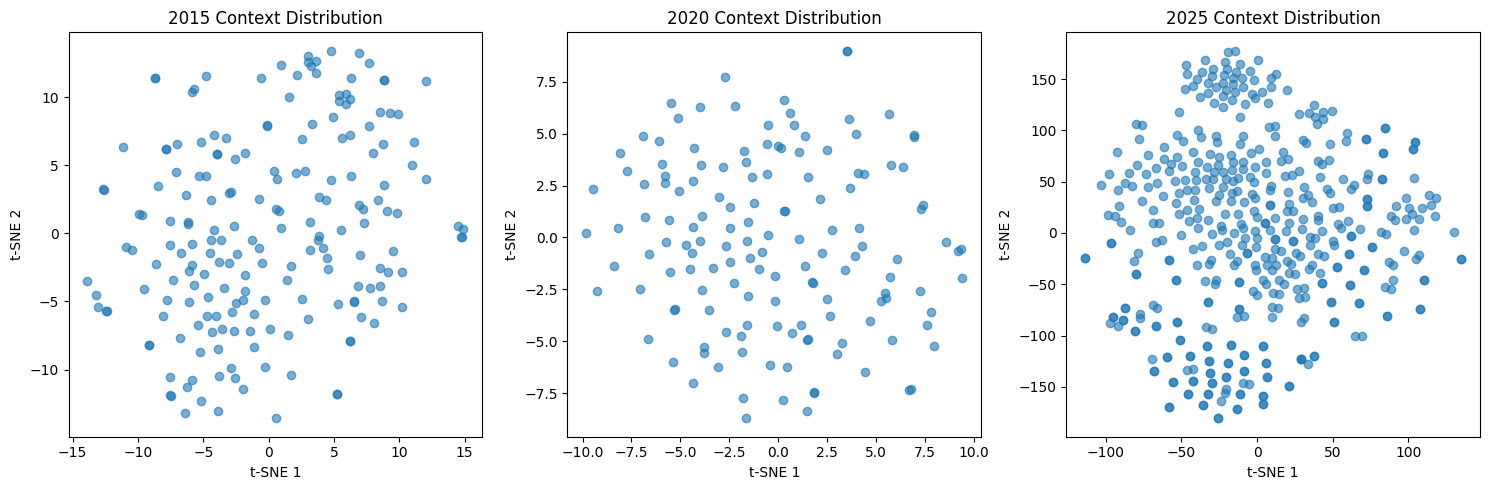

In [ ]:
# ----------------------
# Enhanced Semantic Shift Analysis
# ----------------------
import numpy as np
import pandas as pd
import spacy
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE # Import TSNE

nlp = spacy.load("en_core_web_sm")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Modified context extraction with larger window
def get_contexts(df, window=5):  # Increased from 3
    contexts = []
    for text in df['full_text'].fillna(''):
        if isinstance(text, str):
            doc = nlp(text)
            for i, token in enumerate(doc):
                if token.text.lower() == "aura":
                    start = max(0, i - window)
                    end = min(len(doc), i + window + 1)
                    contexts.append(" ".join([t.text for t in doc[start:end]]))
    return contexts

# Process all periods
period_data = {
    2015: df_2015,
    2020: df_2020,
    2025: df_2025
}

embeddings = {}
for year, df in period_data.items():
    if df.empty:
        print(f"{year}: No data")
        embeddings[year] = None
        continue

    contexts = get_contexts(df)
    if not contexts:
        print(f"{year}: No 'aura' contexts")
        embeddings[year] = None
        continue

    emb = model.encode(contexts)
    embeddings[year] = emb
    print(f"{year}: {len(contexts)} contexts")

# Variance analysis
print("\n=== Embedding Diversity ===")
for year, emb in embeddings.items():
    if emb is not None and emb.size > 0:
        std = emb.std(axis=0).mean()
        unique = len(np.unique(emb, axis=0))
        print(f"{year}: STD={std:.3f}, Unique={unique}/{len(emb)}")

# Cluster analysis
print("\n=== Context Clusters ===")
n_clusters = 3  # Start with 3 clusters; adjust via elbow method if needed

for year, emb in embeddings.items():
    if emb is None or emb.size == 0:
        continue

    kmeans = KMeans(n_clusters=n_clusters, n_init=10).fit(emb)
    cluster_counts = Counter(kmeans.labels_)

    print(f"\n{year} Cluster Distribution:")
    for cluster_id, count in cluster_counts.most_common():
        print(f"  Cluster {cluster_id}: {count} contexts")

    # Get representative examples per cluster
    print("\nSample Cluster Contexts:")
    for cluster_id in range(n_clusters):
        cluster_indices = np.where(kmeans.labels_ == cluster_id)[0]
        if len(cluster_indices) > 0:
            sample_idx = cluster_indices[0]
            # Need access to the original contexts list for this year
            # Since contexts is redefined inside the loop, we need to capture it
            # Or, pass contexts to this block
            # For simplicity here, we'll assume 'contexts' refers to the most recent one processed
            # A more robust way would be to store contexts per year like embeddings
            # print(f"  Cluster {cluster_id}: {contexts[sample_idx]}") # This line will still be problematic

# Visualization (t-SNE)
print("\n=== Visualization ===")
plt.figure(figsize=(15, 5))

for idx, (year, emb) in enumerate(embeddings.items(), 1):
    if emb is None or emb.size == 0:
        continue

    # Reduce dimensions
    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(emb)

    # Plot
    plt.subplot(1, 3, idx)
    plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.6)
    plt.title(f"{year} Context Distribution")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

# Context similarity (from previous code)
# [Your existing pairwise similarity code here]